In [1]:
from ase.io import read
import numpy as np
from dscribe.descriptors import SOAP
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
# from mace.calculators import MACECalculator
import os 

train_configs_folder = 'training_configurations'
cand_configs_folder = 'candidate_configurations'
low_std_configs = 'low_std_configuration'


train_configs = [f'{train_configs_folder}/{file}' for file in os.listdir(train_configs_folder) if file.endswith('.in')]
cand_configs = [f'{cand_configs_folder}/{file}' for file in os.listdir(cand_configs_folder) if file.endswith('.in')]
low_std_configs = [f'{low_std_configs}/{file}' for file in os.listdir(low_std_configs) if file.endswith('.in')]

print(train_configs)
print(cand_configs)
print(low_std_configs)

descs = []
labels = []

['training_configurations/geometry.in', 'training_configurations/geometry (2).in', 'training_configurations/geometry (3).in', 'training_configurations/geometry (4).in', 'training_configurations/geometry (5).in', 'training_configurations/geometry (6).in', 'training_configurations/geometry (7).in', 'training_configurations/geometry (8).in', 'training_configurations/geometry (9).in', 'training_configurations/geometry (10).in', 'training_configurations/geometry (11).in', 'training_configurations/geometry (12).in', 'training_configurations/geometry (13).in', 'training_configurations/geometry (14).in', 'training_configurations/geometry (15).in', 'training_configurations/geometry (16).in', 'training_configurations/geometry (17).in', 'training_configurations/geometry (18).in', 'training_configurations/geometry (19).in', 'training_configurations/geometry_atop.in', 'training_configurations/geometry_bridge_1.in', 'training_configurations/geometry_bridge_1_high_coverage.in', 'training_configuratio

In [2]:
print("Loading data and calculating SOAP descriptors...")
for i, conf in enumerate(train_configs):
    # print(conf)
    conf_atoms = read(conf)
    h_indices = []
    for atom in conf_atoms:
        if atom.symbol=='H':
            # print(atom.index)
            h_indices.append(atom.index)
    species = ['Co', 'H'] # Example
    soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=6, average='off')
    d = soap.create(conf_atoms)
    # print(d[h_indices].shape)
    # # d = StandardScaler().fit_transform(soap_descriptors)
    # # d = calculator.get_descriptors(conf_atoms)
    # # print(d.shape)
    descs.append(d[h_indices])
    labels.extend([i] * len(d[h_indices]))

descs = np.vstack(descs)
labels = np.array(labels)

print(descs.shape)
# print(labels)

Loading data and calculating SOAP descriptors...
(54, 952)


In [3]:
from sklearn.decomposition import PCA

print("Performing t-SNE for initial data visualization...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1, init='pca')
descs_tsne = tsne.fit_transform(descs)


train_configs_pc1 = []
train_configs_pc2 = []

import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 5))

for i in np.unique(labels):
    mask = labels == i
    # print(mask)
    train_configs_pc1.append(np.mean(descs_tsne[mask, 0]))
    train_configs_pc2.append(np.mean(descs_tsne[mask, 1]))

Performing t-SNE for initial data visualization...


In [4]:
descs = []
labels = []

for i, conf in enumerate(low_std_configs):
    conf_atoms = read(conf)
    h_indices = []
    for atom in conf_atoms:
        if atom.symbol=='H':
            # print(atom.index)
            h_indices.append(atom.index)
    species = ['Co', 'H'] # Example
    soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=6, average='off')
    d = soap.create(conf_atoms)
    # print(d[h_indices].shape)
    # # d = StandardScaler().fit_transform(soap_descriptors)
    # # d = calculator.get_descriptors(conf_atoms)
    # # print(d.shape)
    descs.append(d[h_indices])
    labels.extend([i] * len(d[h_indices]))

descs = np.vstack(descs)
labels = np.array(labels)

print(descs.shape)
print(labels.shape)

# from sklearn.decomposition import PCA

print("Performing t-SNE for initial data visualization...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1, init='pca')
descs_tsne = tsne.fit_transform(descs)

# pca = PCA(n_components=2, whiten=True)
# descs_pca = pca.fit_transform(descs)

# print("Explained variance:", pca.explained_variance_ratio_)

low_std_configs_pc1 = []
low_std_configs_pc2 = []

for i in np.unique(labels):
    mask = labels == i
    low_std_configs_pc1.append(np.mean(descs_tsne[mask, 0]))
    low_std_configs_pc2.append(np.mean(descs_tsne[mask, 1]))

(53, 952)
(53,)
Performing t-SNE for initial data visualization...


Performing t-SNE for initial data visualization...


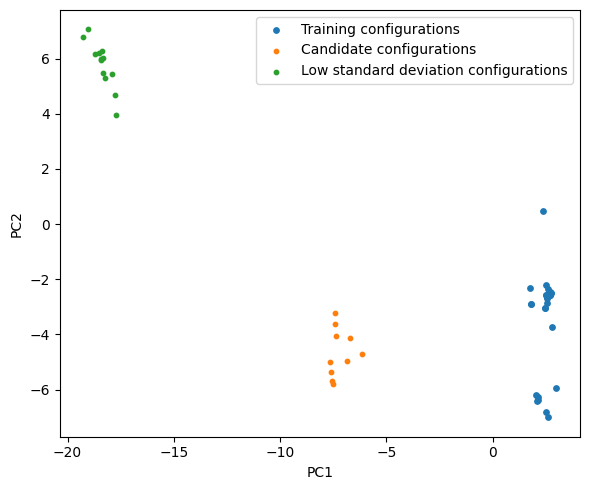

In [8]:
descs = []
labels = []

for i, conf in enumerate(cand_configs):
    conf_atoms = read(conf)
    h_indices = []
    for atom in conf_atoms:
        if atom.symbol=='H':
            # print(atom.index)
            h_indices.append(atom.index)
    species = ['Co', 'H'] # Example
    soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=6, average='off')
    d = soap.create(conf_atoms)
    # print(d[h_indices].shape)
    # # d = StandardScaler().fit_transform(soap_descriptors)
    # # d = calculator.get_descriptors(conf_atoms)
    # # print(d.shape)
    descs.append(d[h_indices])
    labels.extend([i] * len(d[h_indices]))

descs = np.vstack(descs)
labels = np.array(labels)

# from sklearn.decomposition import PCA

print("Performing t-SNE for initial data visualization...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1, init='pca')
descs_tsne = tsne.fit_transform(descs)

# pca = PCA(n_components=2, whiten=True)
# descs_pca = pca.fit_transform(descs)

# print("Explained variance:", pca.explained_variance_ratio_)

cand_configs_pc1 = []
cand_configs_pc2 = []

for i in np.unique(labels):
    mask = labels == i
    cand_configs_pc1.append(np.mean(descs_tsne[mask, 0]))
    cand_configs_pc2.append(np.mean(descs_tsne[mask, 1]))

plt.figure(figsize=(6, 5))
plt.scatter(train_configs_pc1, train_configs_pc2, s=15,label=f'Training configurations')
plt.scatter(cand_configs_pc1, cand_configs_pc2, s=10,label=f'Candidate configurations')
plt.scatter(low_std_configs_pc1, low_std_configs_pc2, s=10,label=f'Low standard deviation configurations')
#
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
# plt.title('Principle components of training and candidate configurations')
plt.tight_layout()
plt.savefig('tSNE analysis - SOAP for H adatoms with low std configurations.jpg', dpi=300)
plt.show()